In [56]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns

In [57]:
data=pd.read_csv('fake_social_media_global_2.0_with_missing.csv')

##  Exploratory Data Analysis (EDA)

In [58]:
data.head()

,platform,has_profile_pic,bio_length,username_randomness,followers,following,follower_following_ratio,account_age_days,posts,posts_per_day,caption_similarity_score,content_similarity_score,follow_unfollow_rate,spam_comments_rate,generic_comment_rate,suspicious_links_in_bio,verified,is_fake,username,username_length,digits_count,digit_ratio,special_char_count,repeat_char_count
0,X,1.0,180.0,1.0,431.0,679.0,0.633824,NaN,NaN,0.205945,0.699444,0.579354,456.0,NaN,5.0,1.0,0.0,0,dmitri,6,0,0.000000,0,0
1,NaN,1.0,214.0,NaN,426.0,729.0,0.583562,3164.0,202.0,0.063823,NaN,0.102866,98.0,NaN,141.0,NaN,1.0,1,smpni6240,9,4,0.444444,0,0
2,X,1.0,87.0,NaN,426.0,721.0,0.590028,903.0,225.0,0.248894,0.858450,0.310863,136.0,171.0,62.0,1.0,0.0,1,qgph5q343j,10,4,0.400000,0,0
3,X,0.0,72.0,0.0,385.0,NaN,0.566176,3433.0,175.0,0.050961,0.176471,0.076058,186.0,46.0,117.0,1.0,1.0,0,mia,3,0,0.000000,0,0
4,Instagram,0.0,162.0,NaN,392.0,709.0,0.552113,NaN,207.0,0.162992,0.265957,0.556130,35.0,184.0,64.0,NaN,1.0,0,martin,6,0,0.000000,0,0


In [59]:
pd.set_option('display.max_columns', None)
display(data.head())

,platform,has_profile_pic,bio_length,username_randomness,followers,following,follower_following_ratio,account_age_days,posts,posts_per_day,caption_similarity_score,content_similarity_score,follow_unfollow_rate,spam_comments_rate,generic_comment_rate,suspicious_links_in_bio,verified,is_fake,username,username_length,digits_count,digit_ratio,special_char_count,repeat_char_count
0,X,1.0,180.0,1.0,431.0,679.0,0.633824,NaN,NaN,0.205945,0.699444,0.579354,456.0,NaN,5.0,1.0,0.0,0,dmitri,6,0,0.000000,0,0
1,NaN,1.0,214.0,NaN,426.0,729.0,0.583562,3164.0,202.0,0.063823,NaN,0.102866,98.0,NaN,141.0,NaN,1.0,1,smpni6240,9,4,0.444444,0,0
2,X,1.0,87.0,NaN,426.0,721.0,0.590028,903.0,225.0,0.248894,0.858450,0.310863,136.0,171.0,62.0,1.0,0.0,1,qgph5q343j,10,4,0.400000,0,0
3,X,0.0,72.0,0.0,385.0,NaN,0.566176,3433.0,175.0,0.050961,0.176471,0.076058,186.0,46.0,117.0,1.0,1.0,0,mia,3,0,0.000000,0,0
4,Instagram,0.0,162.0,NaN,392.0,709.0,0.552113,NaN,207.0,0.162992,0.265957,0.556130,35.0,184.0,64.0,NaN,1.0,0,martin,6,0,0.000000,0,0


In [60]:
data.shape

(3000, 24)

In [61]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   platform                  2667 non-null   object 
 1   has_profile_pic           2655 non-null   float64
 2   bio_length                2671 non-null   float64
 3   username_randomness       2663 non-null   float64
 4   followers                 2662 non-null   float64
 5   following                 2667 non-null   float64
 6   follower_following_ratio  2644 non-null   float64
 7   account_age_days          2657 non-null   float64
 8   posts                     2683 non-null   float64
 9   posts_per_day             2689 non-null   float64
 10  caption_similarity_score  2670 non-null   float64
 11  content_similarity_score  2672 non-null   float64
 12  follow_unfollow_rate      2692 non-null   float64
 13  spam_comments_rate        2662 non-null   float64
 14  generic_

In [62]:
data.describe()

,has_profile_pic,bio_length,username_randomness,followers,following,follower_following_ratio,account_age_days,posts,posts_per_day,caption_similarity_score,content_similarity_score,follow_unfollow_rate,spam_comments_rate,generic_comment_rate,suspicious_links_in_bio,verified,is_fake,username_length,digits_count,digit_ratio,special_char_count,repeat_char_count
count,2655.000000,2671.000000,2663.000000,2662.000000,2667.000000,2644.000000,2657.000000,2683.000000,2689.000000,2670.000000,2672.000000,2692.000000,2662.000000,2633.000000,2640.000000,2663.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,0.492655,124.181206,0.503192,399.984222,700.841395,0.570651,2490.854347,200.295937,0.273948,0.503490,0.496274,249.727712,99.440270,74.568173,0.503409,0.494931,0.353000,9.057333,3.051333,0.314868,0.540000,0.335000
std,0.500040,71.199830,0.500084,20.082031,25.841196,0.035102,1436.750871,14.233918,1.693301,0.286027,0.289539,144.844580,57.970155,43.672848,0.500083,0.500068,0.477982,2.215479,1.777381,0.183668,0.498481,0.544861
min,0.000000,0.000000,0.000000,334.000000,616.000000,0.467377,2.000000,151.000000,0.034999,0.000146,0.000649,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,65.000000,0.000000,387.000000,684.000000,0.545967,1247.000000,190.000000,0.053500,0.259749,0.250974,123.000000,49.000000,36.000000,0.000000,0.000000,0.000000,8.000000,2.000000,0.166667,0.000000,0.000000
50%,0.000000,124.000000,1.000000,400.000000,701.000000,0.570800,2455.000000,200.000000,0.080808,0.510672,0.491510,252.000000,100.000000,76.000000,1.000000,0.000000,0.000000,9.000000,4.000000,0.400000,1.000000,0.000000
75%,1.000000,184.500000,1.000000,413.000000,718.000000,0.593853,3746.000000,209.000000,0.160743,0.748773,0.751249,376.250000,149.000000,111.000000,1.000000,1.000000,1.000000,10.000000,4.000000,0.444444,1.000000,1.000000
max,1.000000,249.000000,1.000000,472.000000,789.000000,0.693679,4997.000000,254.000000,73.333333,0.999496,0.999891,499.000000,199.000000,149.000000,1.000000,1.000000,1.000000,14.000000,8.000000,0.800000,1.000000,3.000000


In [63]:
data.columns

Index(['platform', 'has_profile_pic', 'bio_length', 'username_randomness',
       'followers', 'following', 'follower_following_ratio',
       'account_age_days', 'posts', 'posts_per_day',
       'caption_similarity_score', 'content_similarity_score',
       'follow_unfollow_rate', 'spam_comments_rate', 'generic_comment_rate',
       'suspicious_links_in_bio', 'verified', 'is_fake', 'username',
       'username_length', 'digits_count', 'digit_ratio', 'special_char_count',
       'repeat_char_count'],
      dtype='object')

In [64]:
data.isnull().sum()

,0
platform,333
has_profile_pic,345
bio_length,329
username_randomness,337
followers,338
following,333
follower_following_ratio,356
account_age_days,343
posts,317
posts_per_day,311


In [65]:
missing_percentages = data.isnull().sum() / len(data) * 100
print("Percentage of missing values per column:")
display(missing_percentages[missing_percentages > 0].sort_values(ascending=False))

Percentage of missing values per column:


,0
generic_comment_rate,12.233333
suspicious_links_in_bio,12.000000
follower_following_ratio,11.866667
has_profile_pic,11.500000
account_age_days,11.433333
followers,11.266667
spam_comments_rate,11.266667
verified,11.233333
username_randomness,11.233333
platform,11.100000


In [66]:
num_cols = data.select_dtypes(include=['int64', 'float64']).columns
cat_cols = data.select_dtypes(include=['object']).columns

In [67]:
data[num_cols] = data[num_cols].fillna(data[num_cols].median())
for col in cat_cols:
    data[col].fillna(data[col].mode()[0], inplace=True)
    bool_cols = ['has_profile_pic', 'verified', 'suspicious_links_in_bio']
for col in bool_cols:
    if col in data.columns:
        data[col].fillna(0, inplace=True)

/tmp/ipykernel_3647/1726571486.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].mode()[0], inplace=True)
/tmp/ipykernel_3647/1726571486.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', t

In [68]:
print(data.isnull().sum())

platform                    0
has_profile_pic             0
bio_length                  0
username_randomness         0
followers                   0
following                   0
follower_following_ratio    0
account_age_days            0
posts                       0
posts_per_day               0
caption_similarity_score    0
content_similarity_score    0
follow_unfollow_rate        0
spam_comments_rate          0
generic_comment_rate        0
suspicious_links_in_bio     0
verified                    0
is_fake                     0
username                    0
username_length             0
digits_count                0
digit_ratio                 0
special_char_count          0
repeat_char_count           0
dtype: int64


In [69]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   platform                  3000 non-null   object 
 1   has_profile_pic           3000 non-null   float64
 2   bio_length                3000 non-null   float64
 3   username_randomness       3000 non-null   float64
 4   followers                 3000 non-null   float64
 5   following                 3000 non-null   float64
 6   follower_following_ratio  3000 non-null   float64
 7   account_age_days          3000 non-null   float64
 8   posts                     3000 non-null   float64
 9   posts_per_day             3000 non-null   float64
 10  caption_similarity_score  3000 non-null   float64
 11  content_similarity_score  3000 non-null   float64
 12  follow_unfollow_rate      3000 non-null   float64
 13  spam_comments_rate        3000 non-null   float64
 14  generic_

<Axes: >

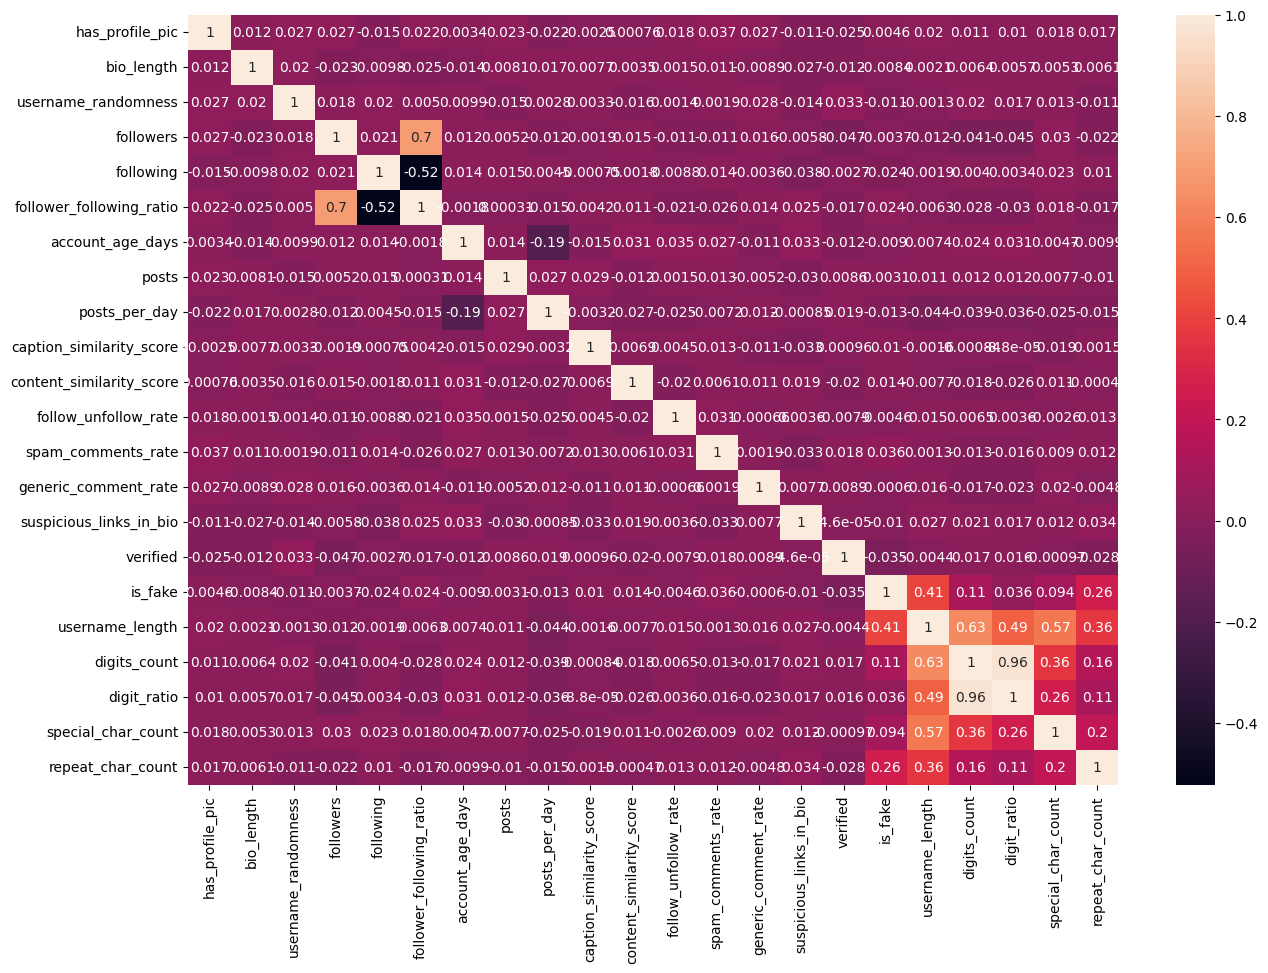

In [70]:
plt.figure(figsize=(15, 10))
sns.heatmap(data.corr(numeric_only=True),annot=True)

# Data Preprocessing

In [71]:
data = pd.get_dummies(data, columns=['platform'], drop_first=False)
display(data.head())

,has_profile_pic,bio_length,username_randomness,followers,following,follower_following_ratio,account_age_days,posts,posts_per_day,caption_similarity_score,content_similarity_score,follow_unfollow_rate,spam_comments_rate,generic_comment_rate,suspicious_links_in_bio,verified,is_fake,username,username_length,digits_count,digit_ratio,special_char_count,repeat_char_count,platform_Facebook,platform_Instagram,platform_X
0,1.0,180.0,1.0,431.0,679.0,0.633824,2455.0,200.0,0.205945,0.699444,0.579354,456.0,100.0,5.0,1.0,0.0,0,dmitri,6,0,0.000000,0,0,False,False,True
1,1.0,214.0,1.0,426.0,729.0,0.583562,3164.0,202.0,0.063823,0.510672,0.102866,98.0,100.0,141.0,1.0,1.0,1,smpni6240,9,4,0.444444,0,0,False,True,False
2,1.0,87.0,1.0,426.0,721.0,0.590028,903.0,225.0,0.248894,0.858450,0.310863,136.0,171.0,62.0,1.0,0.0,1,qgph5q343j,10,4,0.400000,0,0,False,False,True
3,0.0,72.0,0.0,385.0,701.0,0.566176,3433.0,175.0,0.050961,0.176471,0.076058,186.0,46.0,117.0,1.0,1.0,0,mia,3,0,0.000000,0,0,False,False,True
4,0.0,162.0,1.0,392.0,709.0,0.552113,2455.0,207.0,0.162992,0.265957,0.556130,35.0,184.0,64.0,1.0,1.0,0,martin,6,0,0.000000,0,0,False,True,False


In [72]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   has_profile_pic           3000 non-null   float64
 1   bio_length                3000 non-null   float64
 2   username_randomness       3000 non-null   float64
 3   followers                 3000 non-null   float64
 4   following                 3000 non-null   float64
 5   follower_following_ratio  3000 non-null   float64
 6   account_age_days          3000 non-null   float64
 7   posts                     3000 non-null   float64
 8   posts_per_day             3000 non-null   float64
 9   caption_similarity_score  3000 non-null   float64
 10  content_similarity_score  3000 non-null   float64
 11  follow_unfollow_rate      3000 non-null   float64
 12  spam_comments_rate        3000 non-null   float64
 13  generic_comment_rate      3000 non-null   float64
 14  suspicio

In [73]:
for col in ['platform_Facebook', 'platform_Instagram', 'platform_X']:
    data[col] = data[col].astype(int)

In [74]:

data = data.drop(columns=['username'])

In [75]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   has_profile_pic           3000 non-null   float64
 1   bio_length                3000 non-null   float64
 2   username_randomness       3000 non-null   float64
 3   followers                 3000 non-null   float64
 4   following                 3000 non-null   float64
 5   follower_following_ratio  3000 non-null   float64
 6   account_age_days          3000 non-null   float64
 7   posts                     3000 non-null   float64
 8   posts_per_day             3000 non-null   float64
 9   caption_similarity_score  3000 non-null   float64
 10  content_similarity_score  3000 non-null   float64
 11  follow_unfollow_rate      3000 non-null   float64
 12  spam_comments_rate        3000 non-null   float64
 13  generic_comment_rate      3000 non-null   float64
 14  suspicio

In [76]:
display(data.head())

,has_profile_pic,bio_length,username_randomness,followers,following,follower_following_ratio,account_age_days,posts,posts_per_day,caption_similarity_score,content_similarity_score,follow_unfollow_rate,spam_comments_rate,generic_comment_rate,suspicious_links_in_bio,verified,is_fake,username_length,digits_count,digit_ratio,special_char_count,repeat_char_count,platform_Facebook,platform_Instagram,platform_X
0,1.0,180.0,1.0,431.0,679.0,0.633824,2455.0,200.0,0.205945,0.699444,0.579354,456.0,100.0,5.0,1.0,0.0,0,6,0,0.000000,0,0,0,0,1
1,1.0,214.0,1.0,426.0,729.0,0.583562,3164.0,202.0,0.063823,0.510672,0.102866,98.0,100.0,141.0,1.0,1.0,1,9,4,0.444444,0,0,0,1,0
2,1.0,87.0,1.0,426.0,721.0,0.590028,903.0,225.0,0.248894,0.858450,0.310863,136.0,171.0,62.0,1.0,0.0,1,10,4,0.400000,0,0,0,0,1
3,0.0,72.0,0.0,385.0,701.0,0.566176,3433.0,175.0,0.050961,0.176471,0.076058,186.0,46.0,117.0,1.0,1.0,0,3,0,0.000000,0,0,0,0,1
4,0.0,162.0,1.0,392.0,709.0,0.552113,2455.0,207.0,0.162992,0.265957,0.556130,35.0,184.0,64.0,1.0,1.0,0,6,0,0.000000,0,0,0,1,0


### Data Visualization

<Axes: >

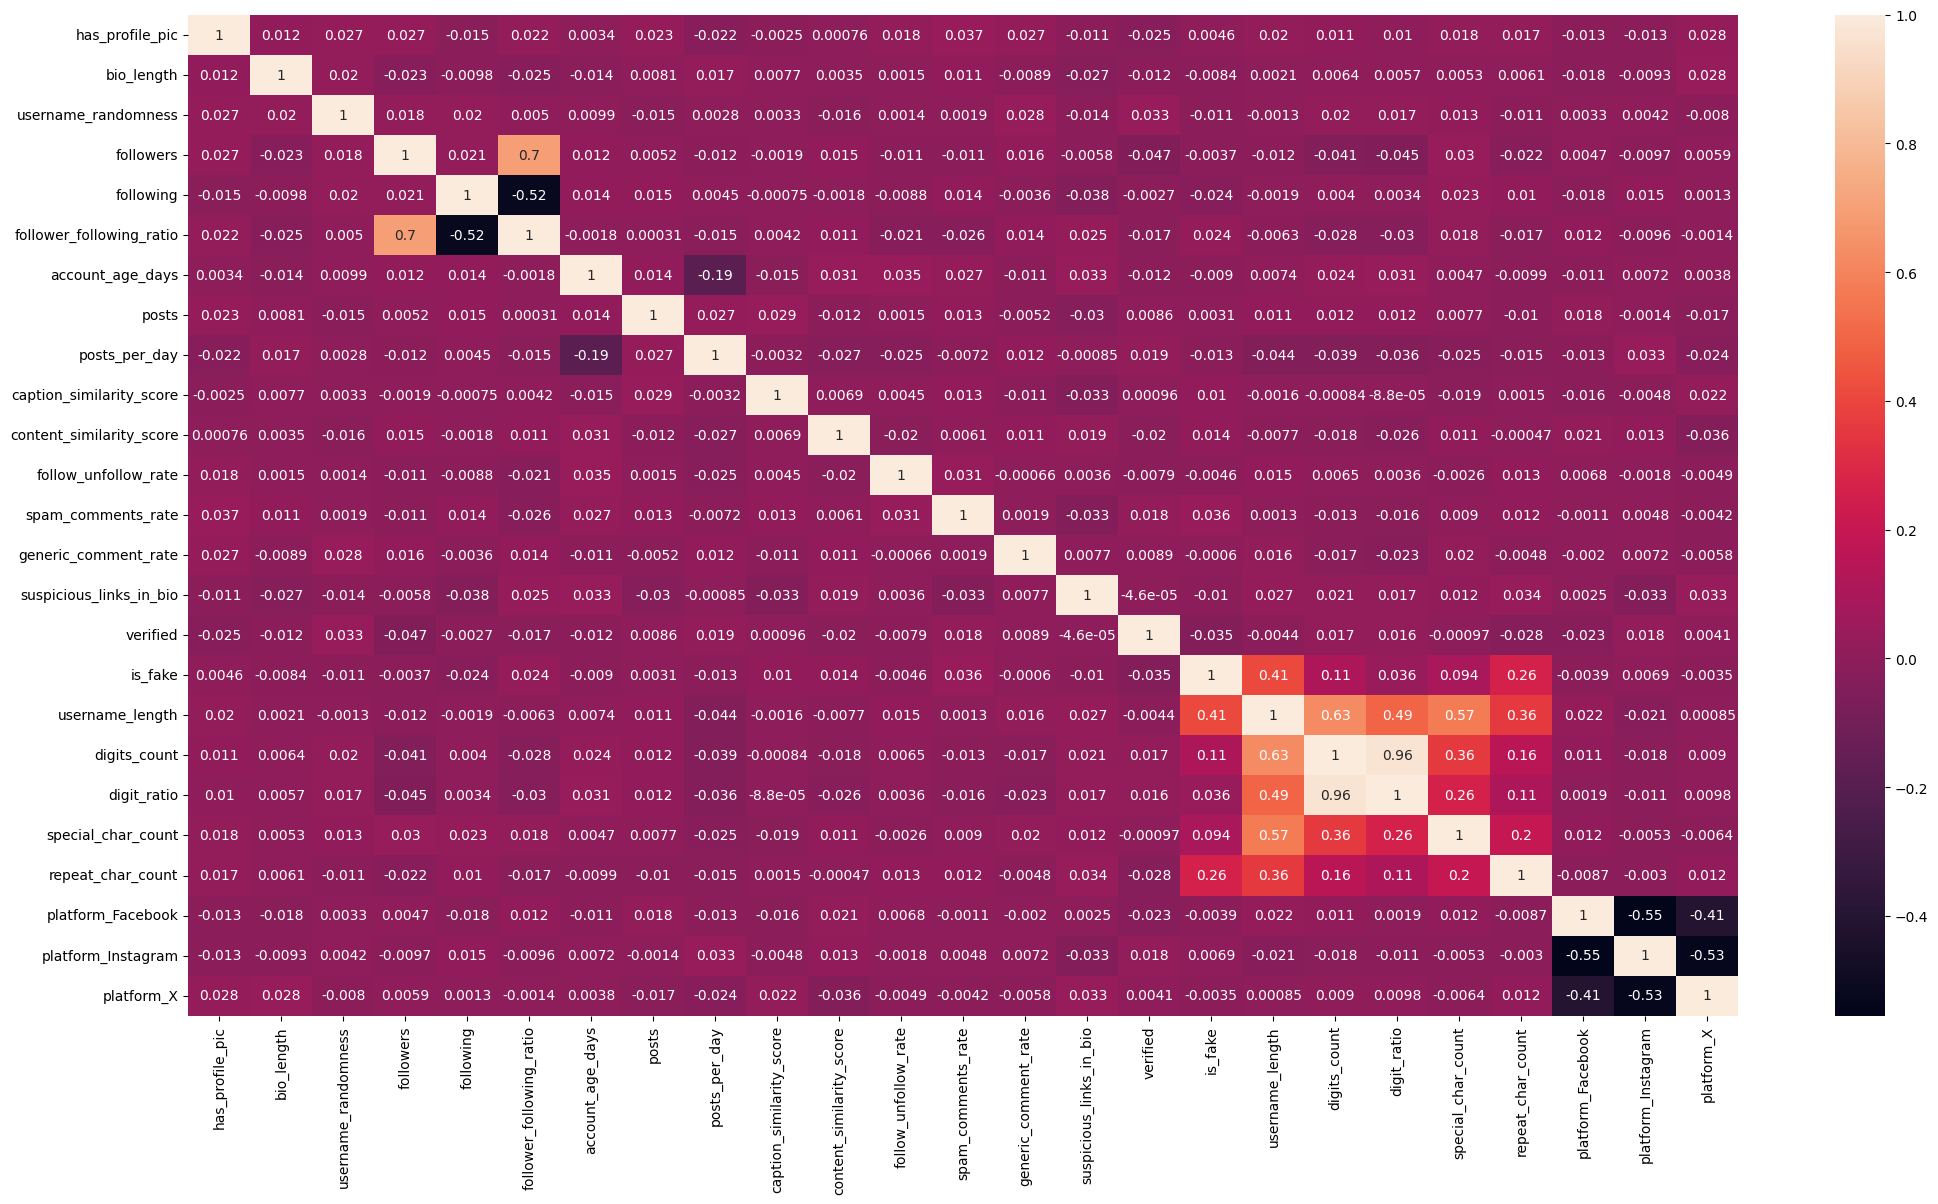

In [77]:
plt.figure(figsize=(25,13))
sns.heatmap(data.corr(numeric_only=True),annot=True)

In [78]:
data.drop(['digit_ratio'], axis=1, inplace=True)
data.drop([
    'bio_length',
    'caption_similarity_score',
    'content_similarity_score',
    'follow_unfollow_rate'
], axis=1, inplace=True)



In [79]:
print(data.shape)

(3000, 20)


In [80]:
X = data.drop('is_fake', axis=1)
y = data['is_fake']

## Model Building/Model Evaluation                                                                                                                                                                                   






In [81]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [82]:
from sklearn.linear_model import LogisticRegression

model_LR = LogisticRegression(max_iter=1000)
model_LR.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [83]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler



In [84]:
model_LR.fit(X_train, y_train)
y_pred = model_LR.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n",confusion_matrix(y_test, y_pred))
print("Classification Report:\n",classification_report(y_test, y_pred))

Accuracy: 0.7016666666666667
Confusion Matrix:
 [[341  49]
 [130  80]]
Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.87      0.79       390
           1       0.62      0.38      0.47       210

    accuracy                           0.70       600
   macro avg       0.67      0.63      0.63       600
weighted avg       0.69      0.70      0.68       600



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [85]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_LRS= LogisticRegression(max_iter=1000)
model_LRS.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [86]:

y_pred = model_LRS.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n",confusion_matrix(y_test, y_pred))
print("Classification Report:\n",classification_report(y_test, y_pred))

Accuracy: 0.6933333333333334
Confusion Matrix:
 [[338  52]
 [132  78]]
Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.87      0.79       390
           1       0.60      0.37      0.46       210

    accuracy                           0.69       600
   macro avg       0.66      0.62      0.62       600
weighted avg       0.68      0.69      0.67       600



In [87]:
from sklearn.neighbors import KNeighborsClassifier


In [88]:
knn_model=KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [89]:
y_pred_knn=knn_model.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Confusion Matrix:\n",confusion_matrix(y_test, y_pred_knn))
print("Classification Report:\n",classification_report(y_test, y_pred_knn))

Accuracy: 0.7216666666666667
Confusion Matrix:
 [[345  45]
 [122  88]]
Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.88      0.81       390
           1       0.66      0.42      0.51       210

    accuracy                           0.72       600
   macro avg       0.70      0.65      0.66       600
weighted avg       0.71      0.72      0.70       600



In [90]:
from sklearn.naive_bayes import GaussianNB


In [91]:
model_NB=GaussianNB()
model_NB.fit(X_train_scaled, y_train)

GaussianNB()

In [92]:
y_pred_NB=model_NB.predict(X_test_scaled)

In [93]:
print("Accuracy:", accuracy_score(y_test, y_pred_NB))
print("Confusion Matrix:\n",confusion_matrix(y_test, y_pred_NB))
print("Classification Report:\n",classification_report(y_test, y_pred_NB))

Accuracy: 0.5633333333333334
Confusion Matrix:
 [[169 221]
 [ 41 169]]
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.43      0.56       390
           1       0.43      0.80      0.56       210

    accuracy                           0.56       600
   macro avg       0.62      0.62      0.56       600
weighted avg       0.67      0.56      0.56       600



In [94]:
from sklearn.tree import DecisionTreeClassifier

In [95]:
model_DT=DecisionTreeClassifier(random_state=42)
model_DT.fit(X_train_scaled, y_train)

DecisionTreeClassifier(random_state=42)

In [96]:
y_pred_DT=model_DT.predict(X_test_scaled)

In [97]:
print("Accuracy:", accuracy_score(y_test, y_pred_DT))
print("Confusion Matrix:\n",confusion_matrix(y_test, y_pred_DT))
print("Classification Report:\n",classification_report(y_test, y_pred_DT))

Accuracy: 0.9083333333333333
Confusion Matrix:
 [[363  27]
 [ 28 182]]
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.93      0.93       390
           1       0.87      0.87      0.87       210

    accuracy                           0.91       600
   macro avg       0.90      0.90      0.90       600
weighted avg       0.91      0.91      0.91       600



In [98]:
from sklearn.svm import SVC

In [99]:
model_svm=SVC(kernel='rbf')
model_svm.fit(X_train_scaled, y_train)

SVC()

In [100]:
y_pred_svm=model_svm.predict(X_test_scaled)

In [101]:
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Confusion Matrix:\n",confusion_matrix(y_test, y_pred_svm))
print("Classification Report:\n",classification_report(y_test, y_pred_svm))

Accuracy: 0.795
Confusion Matrix:
 [[355  35]
 [ 88 122]]
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.91      0.85       390
           1       0.78      0.58      0.66       210

    accuracy                           0.80       600
   macro avg       0.79      0.75      0.76       600
weighted avg       0.79      0.80      0.79       600



In [102]:
from sklearn.ensemble import RandomForestClassifier
model_RF = RandomForestClassifier(random_state=42)
model_RF.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

In [103]:

y_pred_RF = model_RF.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred_RF))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_RF))
print("Classification Report:\n", classification_report(y_test, y_pred_RF))

Accuracy: 0.91
Confusion Matrix:
 [[371  19]
 [ 35 175]]
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.95      0.93       390
           1       0.90      0.83      0.87       210

    accuracy                           0.91       600
   macro avg       0.91      0.89      0.90       600
weighted avg       0.91      0.91      0.91       600



In [104]:
from sklearn.ensemble import GradientBoostingClassifier
model_GB = GradientBoostingClassifier(random_state=42)
model_GB.fit(X_train_scaled, y_train)

GradientBoostingClassifier(random_state=42)

In [105]:
y_pred_GB = model_GB.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred_GB))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_GB))
print("Classification Report:\n", classification_report(y_test, y_pred_GB))

Accuracy: 0.8983333333333333
Confusion Matrix:
 [[368  22]
 [ 39 171]]
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.94      0.92       390
           1       0.89      0.81      0.85       210

    accuracy                           0.90       600
   macro avg       0.90      0.88      0.89       600
weighted avg       0.90      0.90      0.90       600



## Model Saving

In [106]:
import joblib
joblib.dump(model_RF,'model_rf_FSD.pkl')
joblib.dump(scaler,'scaler.pkl')
joblib.dump(X.columns.tolist(),'columns.pkl')


['columns.pkl']